In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
from modules import data_loader, metrics, learning, plotting, utils, params
from models.gmp import GMP
from models.rtdtnn import RTDTNN
from modules import pipelines

import random
import json

Load data from files and init acpr meter

In [4]:
M = 5
P = 3

container = data_loader.DataContainer()
container.load_data(file_path="datasets/Custom_dataset")
container.cut_signals(M=M)
container.get_gained_signals()


acpr_meter = metrics.ACPR(
        sample_rate=container.input_signal_fs,
        main_measurement_bandwidth=container.bw_main_ch,
        adjacent_channel_offset=[-container.sub_ch, container.sub_ch],
        segment_length=container.nperseg,
        overlap_percentage=60,
        window='blackmanharris',
        fft_length=container.nperseg,
        power_units='dBW',
        return_main_power=True,
        return_adjacent_powers=True
    )


In [5]:
batch_size = 128
batch_size_eval = 2048


# pa_train_loader_transformer, pa_val_loader_transformer = data_loader.build_RTDTNN_dataloaders(container, batch_size=batch_size, batch_size_eval=batch_size_eval, M=M, P=P, arch="pa")
# dla_train_loader_transformer, dla_val_loader_transformer = data_loader.build_RTDTNN_dataloaders(container, batch_size=batch_size, batch_size_eval=batch_size_eval, M=M, P=P, arch="dla")
# ila_train_loader_transformer, ila_val_loader_transformer = data_loader.build_RTDTNN_dataloaders(container, batch_size=batch_size, batch_size_eval=batch_size_eval, M=M, P=P, arch="ila")
# ilc_train_loader_transformer, ilc_val_loader_transformer = data_loader.build_RTDTNN_dataloaders(container, batch_size=batch_size, batch_size_eval=batch_size_eval, M=M, P=P, arch="ilc")

criterion = metrics.compute_mse
metric_criterion = metrics.compute_nmse

feature_extractor = data_loader.build_RTDTNN_features

In [ ]:
# frame_length = 64
# batch_size = 256
# batch_size_eval = 2048

# pa_train_loader, pa_val_loader = data_loader.build_dataloaders(data_dict=container.to_dict(), frame_length=frame_length, batch_size=batch_size, batch_size_eval=batch_size_eval)
# dla_train_loader, dla_val_loader = data_loader.build_dataloaders(data_dict=container.to_dict(), frame_length=frame_length, batch_size=batch_size, batch_size_eval=batch_size_eval, arch="dla")
# ila_train_loader, ila_val_loader = data_loader.build_dataloaders(data_dict=container.to_dict(), frame_length=frame_length, batch_size=batch_size, batch_size_eval=batch_size_eval, arch="ila")

# criterion = metrics.compute_mse
# metric_criterion = metrics.compute_nmse

PA

In [6]:

criterion_pa = metrics.compute_nmse

pa_degree = 6
pa_config = params.make_gmp_params(
    Ka=pa_degree,
    La=pa_degree,
    Kb=pa_degree,
    Lb=pa_degree,
    Mb=pa_degree,
    Kc=pa_degree,
    Lc=pa_degree,
    Mc=pa_degree,
)

pa_model = GMP(**pa_config, model_name="pa")


print(f"total_params: {pa_model.count_params()}")

epochs = 10
lr = 0.001

optimizer = torch.optim.Adam(pa_model.parameters(), lr=lr)

if not pa_model.load_weights():
      learning.train(net=pa_model, 
            criterion=criterion_pa, 
            optimizer=optimizer, 
            train_loader=pa_train_loader, 
            val_loader=pa_val_loader, 
            n_epochs=epochs, 
            metric_criterion=metric_criterion)
      pa_model.save_weights()
utils.freeze_model(pa_model)

y_val_pa_gmp = learning.net_inference(net=pa_model, x=container.val_input)
pa_nmse_gmp = metrics.compute_nmse(y_val_pa_gmp, container.val_output)
print(f"Model NMSE: {pa_nmse_gmp:.2f}")

total_params: 936
Model weights loaded from model_params/pa_GMP_Ka6_La6_Kb6_Lb6_Mb6_Kc6_Lc6_Mc6.pt
Model NMSE: -40.75


c:\Users\maximp\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\signal\_spectral_py.py:652: UserWarning: Input data is complex, switching to return_onesided=False
  freqs, Pxx = csd(x, x, fs=fs, window=window, nperseg=nperseg,


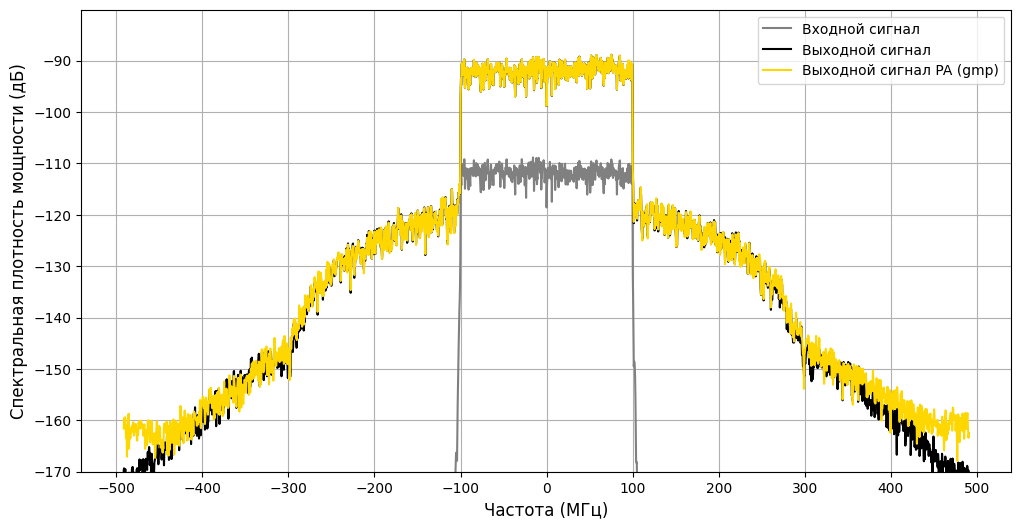

In [7]:
window_size = 0

freqs, spectrum_x_val = metrics.power_spectrum(container.val_input, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val = metrics.power_spectrum(container.val_output, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_pa_gmp = metrics.power_spectrum(y_val_pa_gmp, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_pa_base = metrics.power_spectrum(y_val_pa_base, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_pa_alibi = metrics.power_spectrum(y_val_pa_alibi, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_pa_relative = metrics.power_spectrum(y_val_pa_relative, container.input_signal_fs, container.nperseg, window_size)


xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_x_val, color='grey', label='Входной сигнал')
plt.plot(freqs / 1e6, spectrum_y_val, color='black', label='Выходной сигнал')
plt.plot(freqs / 1e6, spectrum_pa_gmp, color='gold', label='Выходной сигнал PA (gmp)')
# plt.plot(freqs / 1e6, spectrum_pa_base, color='purple', label='Выходной сигнал PA (base)')
# plt.plot(freqs / 1e6, spectrum_pa_alibi, color='orange', label='Выходной сигнал PA (alibi)')
# plt.plot(freqs / 1e6, spectrum_pa_relative, color='coral', label='Выходной сигнал PA (relative)')


plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.ylim(bottom=-170)
plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()


In [ ]:
# with torch.autograd.profiler.profile(use_cuda=False) as prof:
#     with torch.no_grad():
#         output = pa_model.forward(container.val_input_orig)

# print(prof.key_averages().table(sort_by="cpu_time_total", row_limit=20))

-----------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
-----------------------  ------------  ------------  ------------  ------------  ------------  ------------  
              aten::mul        15.02%     415.212ms        24.41%     674.792ms       3.660us        184350  
              aten::add        16.38%     452.823ms        23.98%     662.833ms       3.595us        184360  
            aten::slice        15.40%     425.657ms        18.68%     516.364ms       2.101us        245795  
               aten::to         3.32%      91.673ms        17.21%     475.607ms       3.440us        138251  
         aten::_to_copy         7.45%     205.875ms        13.89%     383.934ms       4.166us         92169  
            aten::chunk         0.84%      23.184ms         9.59%     264.999ms      17.250us         15362  
          

ILC DPD

In [8]:
u_k_train = learning.ilc_signal(container.train_input, container.train_output_target, pa_model, epochs=200, learning_rate=0.01)
u_k_val = learning.ilc_signal(container.val_input, container.val_output_target, pa_model, epochs=200, learning_rate=0.01)
u_k_pa = pa_model.forward(u_k_train).detach()

nmse_uk_pa = metrics.compute_nmse(u_k_pa, container.train_output_target)
print(f"NMSE на выходе усилителя (ILC): {nmse_uk_pa:.2f} db")

container.ilc_train_output = u_k_train
container.ilc_val_output = u_k_val



Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:02:06
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:32
NMSE на выходе усилителя (ILC): -70.27 db


In [9]:
ilc_train_loader, ilc_val_loader, ilc_input_norm, ilc_target_norm = data_loader.build_nn_dataloaders(container, 
                                                                            batch_size=batch_size, 
                                                                            batch_size_eval=batch_size_eval,
                                                                            arch="ilc",
                                                                            features_extractor=feature_extractor,
                                                                            normalize_method='standard',
                                                                            M=M, 
                                                                            P=P)

In [14]:

model_ilc = RTDTNN(d_in=2+P, 
                  d_model=14, 
                  n_heads=2, 
                  d_ff=8, 
                  n_fc=8, 
                  num_blocks=1,
                  M=M, 
                  model_name="ilc")

print(f"total_params: {model_ilc.count_params()}")

epochs = 400
lr = 0.01

optimizer = torch.optim.AdamW(model_ilc.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

if not model_ilc.load_weights():
      learning.train(net=model_ilc, 
            criterion=criterion, 
            optimizer=optimizer, 
            train_loader=ilc_train_loader, 
            val_loader=ilc_val_loader, 
            n_epochs=epochs, 
            metric_criterion=metric_criterion,
            scheduler=scheduler)
      model_ilc.save_weights()

norm_val_input = ilc_input_norm.transform(container.val_input_orig)
x_val_in = feature_extractor(norm_val_input, M, P)

y_before_pa = learning.net_inference(net=model_ilc, x=x_val_in)
y_before_pa = ilc_target_norm.inverse_transform(y_before_pa)

casc_ilc_eval = utils.CascadeModel(model_1=model_ilc, model_2=pa_model, normalizer=ilc_target_norm)
y_val_ilc = learning.net_inference(net=casc_ilc_eval, x=x_val_in)

ilc_nmse = metrics.compute_nmse(y_val_ilc, container.val_output_target)
print(f"Model NMSE: {ilc_nmse:.2f}")

acpr_no_pe = metrics.calculate_acpr(y_val_ilc, acpr_meter)
print(f"Model ACPR: {acpr_no_pe[0]:.2f} {acpr_no_pe[1]:.2f}")

total_params: 1934
No saved weights found at model_params/ilc_RTDTNN_din5_dmodel14_heads2_dff8_nfc8_M5_blocks1.pt, initializing new parameters.
===Start training===
Epoch 0000 — train_loss: 0.07672194, val_loss: 0.00382497, val_NMSE: -24.09, lr: 0.01
Epoch 0001 — train_loss: 0.00371419, val_loss: 0.00430762, val_NMSE: -23.55, lr: 0.01
Epoch 0002 — train_loss: 0.00239229, val_loss: 0.00158462, val_NMSE: -27.93, lr: 0.01
Epoch 0003 — train_loss: 0.00198909, val_loss: 0.00093699, val_NMSE: -30.24, lr: 0.01
Epoch 0004 — train_loss: 0.00184747, val_loss: 0.00255937, val_NMSE: -25.81, lr: 0.01
Epoch 0005 — train_loss: 0.00180855, val_loss: 0.00213299, val_NMSE: -26.59, lr: 0.01
Epoch 0006 — train_loss: 0.00153289, val_loss: 0.00104628, val_NMSE: -29.71, lr: 0.01
Epoch 0007 — train_loss: 0.00137061, val_loss: 0.00106277, val_NMSE: -29.63, lr: 0.01
Epoch 0008 — train_loss: 0.00158398, val_loss: 0.00076636, val_NMSE: -31.09, lr: 0.01
Epoch 0009 — train_loss: 0.00135326, val_loss: 0.00074991, va

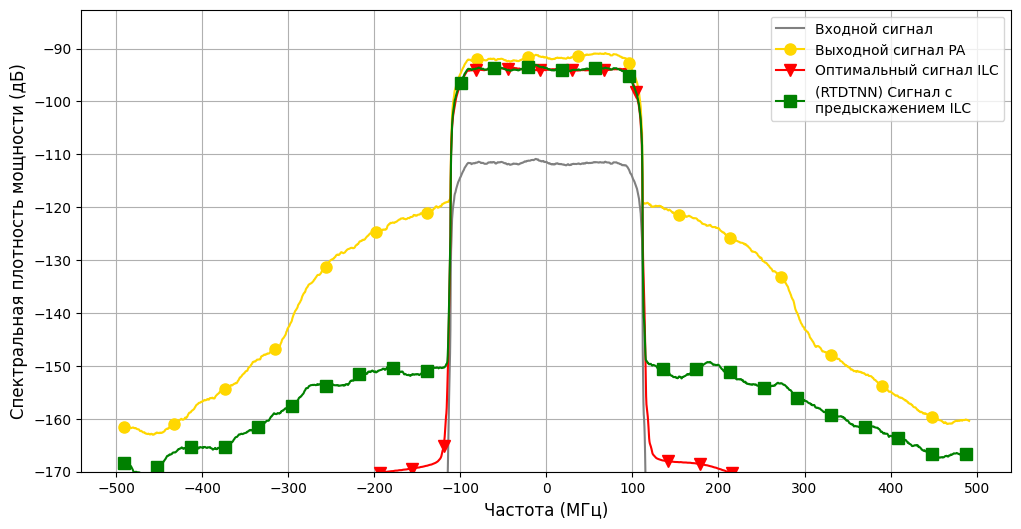

In [55]:
window_size = 50

freqs, spectrum_x_val = metrics.power_spectrum(container.val_input, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val = metrics.power_spectrum(container.val_output, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_pa = metrics.power_spectrum(y_val_pa_gmp, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_before_pa = metrics.power_spectrum(y_before_pa, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_ilc = metrics.power_spectrum(y_val_ilc, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_y_val_pe_ilc = metrics.power_spectrum(y_val_ilc_pe, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_y_val_target = metrics.power_spectrum(container.val_output_target, container.input_signal_fs, container.nperseg, window_size)
_, spectrum_u_k_pa = metrics.power_spectrum(u_k_pa, container.input_signal_fs, container.nperseg, window_size)
# _, spectrum_u_k = metrics.power_spectrum(u_k_train, container.input_signal_fs, container.nperseg, window_size)


xlabel="Частота (МГц)"
ylabel= "Спектральная плотность мощности (дБ)"
fontsize = 12
figsize=(12, 6)
markersize=8

plt.figure(figsize=figsize)

plt.plot(freqs / 1e6, spectrum_x_val, color='grey', label='Входной сигнал')
# plt.plot(freqs / 1e6, spectrum_y_val, color='black', label='Выходной сигнал')
plt.plot(freqs / 1e6, spectrum_y_val_pa, color='gold', label='Выходной сигнал PA', marker='o', markevery=150, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_u_k_pa, color='red', label='Оптимальный сигнал ILC', marker='v', markevery=95, markersize=markersize)
plt.plot(freqs / 1e6, spectrum_y_val_ilc, color='green', label='(RTDTNN) Сигнал с \nпредыскажением ILC', marker='s', markevery=100, markersize=markersize)
# plt.plot(freqs / 1e6, spectrum_y_val_pe_ilc, color='coral', label='(RTDTNN | PE) Сигнал с \nпредыскажением ILC', marker='s', markevery=120, markersize=markersize)
# plt.plot(freqs / 1e6, spectrum_u_k, color='magenta', label='spectrum_u_k')
# plt.plot(freqs / 1e6, spectrum_y_before_pa, label='spectrum_y_before_pa')



plt.xlabel(xlabel, fontsize=fontsize)
plt.ylabel(ylabel, fontsize=fontsize)
plt.ylim(bottom=-170)
plt.xticks(np.arange(-500, 600, 100))
plt.legend()
plt.grid()
plt.show()


Metrics

In [7]:
rtdtnn_train_props = {
    "M": M,
    "P": P,
    "d_in": P+2,
    "d_model": 14,
    "n_heads": 2,
    "d_ff": 8,
    "n_fc": 8,
    "num_blocks": 1,
    "lr": 0.001,
    "epochs": 400,
    "acpr_meter": acpr_meter
}

rtdtnn_pipeline = pipelines.SimplePipeline(container=container, 
                              train_props=rtdtnn_train_props, 
                              base_model=RTDTNN,
                              pa_model=pa_model)


rtdtnn_stats = rtdtnn_pipeline.evaluate_with_statistics(arch='ilc', n_runs=5)

rtdtnn_agg_stats = metrics.summarize_statistics(rtdtnn_stats)

rtdtnn_results = rtdtnn_pipeline.get_results()

rtdtnn_count = rtdtnn_results["ilc"]["count_params"]

final_rtdtnn_stats = {
        "Model": "rtdtnn",
        "Params": rtdtnn_count,
        "NMSE (dB)": round(rtdtnn_agg_stats["nmse"]["mean"], 2),
        "ACPR left (dB)": round(rtdtnn_agg_stats["acpr_l"]["mean"], 2),
        "ACPR right (dB)": round(rtdtnn_agg_stats["acpr_r"]["mean"], 2),
    }

print(final_rtdtnn_stats)


=== Run 1/5 ===
Run ILC
count_params: 1934
Epoch [0/200], Loss: 0.004443641286343336
Epoch [100/200], Loss: 8.294723130575221e-08
Epoch [199/200], Loss: 2.2939243837782897e-09
Выполнение заняло: 0:01:49
Epoch [0/200], Loss: 0.004412407521158457
Epoch [100/200], Loss: 8.252550998122388e-08
Epoch [199/200], Loss: 5.0308555064881855e-12
Выполнение заняло: 0:00:28
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.22960942, val_loss: 0.02589699, val_NMSE: -15.77, lr: 0.001
Epoch 0001 — train_loss: 0.01661192, val_loss: 0.01028075, val_NMSE: -19.79, lr: 0.001
Epoch 0002 — train_loss: 0.00843835, val_loss: 0.00555481, val_NMSE: -22.45, lr: 0.001
Epoch 0003 — train_loss: 0.00541354, val_loss: 0.00386207, val_NMSE: -24.04, lr: 0.001
Epoch 0004 — train_loss: 0.00394282, val_loss: 0.00353606, val_NMSE: -24.41, lr: 0.001
Epoch 0005 — train_loss: 0.00294225, val_loss: 0.00225914, val_NMSE: -26.38, lr: 0.001
Epoch 0006 — train_loss: 0.00235839, val_loss: 0.00192

In [10]:

def append_dict_to_file_json(dictionary, filename='logs/data.json.txt'):
    with open(filename, 'a', encoding='utf-8') as f:
        json.dump(dictionary, f)
        f.write('\n')  # Добавляем перевод строки

def read_dicts_from_json(filename='logs/data.json.txt'):
    read_list = []
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            my_dict = json.loads(line.strip())
            read_list.append(my_dict)
    return read_list

# # Использование:
# append_dict_to_file_json({'name': 'John', 'age': 30})
# append_dict_to_file_json({'name': 'Anna', 'age': 25})

arr = read_dicts_from_json()
print(arr)

FileNotFoundError: [Errno 2] No such file or directory: 'logs/data.json.txt'

In [20]:
def estimate_rtdtnn_params(
    P: int,
    d_in: int,
    d_model: int,
    n_heads: int,
    d_ff: int,
    n_fc: int,
    num_blocks: int
):
    """
    Приближённая оценка числа параметров RTDTNN.
    """

    # input projection
    input_proj = d_in * d_model + d_model

    # transformer blocks
    block_params = 0

    for _ in range(num_blocks):

        # MultiHeadAttention
        # Q, K, V + output projection
        mha = 4 * (d_model * d_model + d_model)

        # FFN
        ffn = (
            d_model * d_ff + d_ff +
            d_ff * d_model + d_model
        )

        # LayerNorm x2
        ln = 4 * d_model

        block_params += mha + ffn + ln

    # FC head
    fc = (
        d_model * n_fc + n_fc +
        n_fc * 2 + 2
    )

    total = input_proj + block_params + fc

    return total


def is_valid_params(params, low=1900, high=2100):
    return low <= params <= high



# d_model_values = [10, 12, 14]
# d_ff_values = [4, 6, 8]
# n_fc_values = [4, 6, 8]

# d_model_values = [12, 14, 16]
# d_ff_values = [6, 8, 10, 12]
# n_fc_values = [6, 8, 10, 12]
# n_heads_values = [2]
# num_blocks_values = [1]

d_model_values = [6, 8, 10]
d_ff_values = [4, 6, 8,]
n_fc_values = [4, 6, 8]
n_heads_values = [2]
num_blocks_values = [1, 2, 3]


candidate_configs = []

for d_model in d_model_values:
    for d_ff in d_ff_values:
        for n_fc in n_fc_values:
            for n_heads in n_heads_values:
                for num_blocks in num_blocks_values:

                    if d_model % n_heads != 0:
                        continue

                    rtdtnn_train_props = {
                        "M": M,
                        "P": P,
                        "d_in": P + 2,
                        "d_model": d_model,
                        "n_heads": n_heads,
                        "d_ff": d_ff,
                        "n_fc": n_fc,
                        "num_blocks": num_blocks,
                        "lr": 0.001,
                        "epochs": 400,
                        "acpr_meter": acpr_meter
                    }

                    pipeline = pipelines.SimplePipeline(
                        container=container,
                        train_props=rtdtnn_train_props,
                        base_model=RTDTNN,
                        pa_model=pa_model
                    )

                    params = pipeline.get_count_params()

                    # print(d_model,d_ff,n_fc,n_heads,params)

                    if 1900 <= params <= 2100:

                        candidate_configs.append({
                            "d_model": d_model,
                            "d_ff": d_ff,
                            "n_fc": n_fc,
                            "n_heads": n_heads,
                            "num_blocks": num_blocks,
                            "params": params
                        })

candidate_configs = random.sample(candidate_configs, len(candidate_configs))

print(f"count candidates: {len(candidate_configs)}")
print(*candidate_configs, sep='\n')

results = []

for cfg in candidate_configs:

    rtdtnn_train_props = {
        "M": M,
        "P": P,
        "d_in": P + 2,
        "d_model": cfg["d_model"],
        "n_heads": cfg["n_heads"],
        "d_ff": cfg["d_ff"],
        "n_fc": cfg["n_fc"],
        "num_blocks": cfg["num_blocks"],
        "lr": 0.001,
        "epochs": 100,
        "acpr_meter": acpr_meter
    }

    pipeline = pipelines.SimplePipeline(
        container=container,
        train_props=rtdtnn_train_props,
        base_model=RTDTNN,
        pa_model=pa_model
    )

    params = pipeline.get_count_params()
    print(f"params: {params}")
    # точная проверка
    if not (1900 <= params <= 2100):
        continue

    stats = pipeline.evaluate_with_statistics(
        arch='ilc',
        n_runs=3
    )

    agg = metrics.summarize_statistics(stats)

    current_results = {
        "cfg": cfg,
        "params": params,
        "nmse": agg["nmse"]["mean"],
        "acpr_l": agg["acpr_l"]["mean"],
        "acpr_r": agg["acpr_r"]["mean"]
    }
    append_dict_to_file_json(current_results)
    # results.append(current_results)

    print(current_results)

count candidates: 1
{'d_model': 10, 'd_ff': 4, 'n_fc': 4, 'n_heads': 2, 'num_blocks': 3, 'params': 2046}
params: 2046

=== Run 1/3 ===
Run ILC
count_params: 2046
[UK] NMSE: -70.27, ACPR: -80.74 -79.25
===Start training===
Epoch 0000 — train_loss: 0.29936394, val_loss: 0.05551123, val_NMSE: -12.45, lr: 0.001
Epoch 0001 — train_loss: 0.03410157, val_loss: 0.02225601, val_NMSE: -16.43, lr: 0.001
Epoch 0002 — train_loss: 0.01613933, val_loss: 0.01071402, val_NMSE: -19.63, lr: 0.001
Epoch 0003 — train_loss: 0.01074026, val_loss: 0.00930765, val_NMSE: -20.23, lr: 0.001
Epoch 0004 — train_loss: 0.00827372, val_loss: 0.00562271, val_NMSE: -22.46, lr: 0.001
Epoch 0005 — train_loss: 0.00629357, val_loss: 0.00446090, val_NMSE: -23.45, lr: 0.001
Epoch 0006 — train_loss: 0.00512413, val_loss: 0.00406483, val_NMSE: -23.85, lr: 0.001
Epoch 0007 — train_loss: 0.00455005, val_loss: 0.00420965, val_NMSE: -23.68, lr: 0.001
Epoch 0008 — train_loss: 0.00350731, val_loss: 0.00271076, val_NMSE: -25.62, lr: 0

In [21]:

results = read_dicts_from_json()

df = pd.DataFrame(results)
df = df.sort_values(['nmse', 'acpr_l', 'acpr_r'])
print(df)

df.head(20)

                                                 cfg  params   nmse  acpr_l  \
0  {'d_model': 14, 'd_ff': 12, 'n_fc': 8, 'n_head...    2050 -43.05  -55.55   
5  {'d_model': 12, 'd_ff': 10, 'n_fc': 12, 'n_hea...    1918 -42.79  -56.73   
4  {'d_model': 14, 'd_ff': 6, 'n_fc': 10, 'n_head...    2050 -42.47  -55.91   
2  {'d_model': 14, 'd_ff': 10, 'n_fc': 8, 'n_head...    1992 -41.93  -55.14   
1  {'d_model': 14, 'd_ff': 8, 'n_fc': 8, 'n_heads...    1934 -41.85  -56.02   
3  {'d_model': 12, 'd_ff': 12, 'n_fc': 12, 'n_hea...    1968 -41.27  -56.50   
6  {'d_model': 16, 'd_ff': 6, 'n_fc': 6, 'n_heads...    2068 -41.20  -56.01   
7  {'d_model': 10, 'd_ff': 4, 'n_fc': 4, 'n_heads...    2046 -39.43  -53.84   

   acpr_r  
0  -56.60  
5  -57.25  
4  -56.45  
2  -56.31  
1  -56.47  
3  -56.51  
6  -55.41  
7  -54.34  


,cfg,params,nmse,acpr_l,acpr_r
0,"{'d_model': 14, 'd_ff': 12, 'n_fc': 8, 'n_head...",2050,-43.05,-55.55,-56.60
5,"{'d_model': 12, 'd_ff': 10, 'n_fc': 12, 'n_hea...",1918,-42.79,-56.73,-57.25
4,"{'d_model': 14, 'd_ff': 6, 'n_fc': 10, 'n_head...",2050,-42.47,-55.91,-56.45
2,"{'d_model': 14, 'd_ff': 10, 'n_fc': 8, 'n_head...",1992,-41.93,-55.14,-56.31
1,"{'d_model': 14, 'd_ff': 8, 'n_fc': 8, 'n_heads...",1934,-41.85,-56.02,-56.47
3,"{'d_model': 12, 'd_ff': 12, 'n_fc': 12, 'n_hea...",1968,-41.27,-56.50,-56.51
6,"{'d_model': 16, 'd_ff': 6, 'n_fc': 6, 'n_heads...",2068,-41.20,-56.01,-55.41
7,"{'d_model': 10, 'd_ff': 4, 'n_fc': 4, 'n_heads...",2046,-39.43,-53.84,-54.34


1	{'d_model': 14, 'd_ff': 8, 'n_fc': 8, 'n_heads': 2, 'num_blocks': 1, 'params': 1934}	1934	-45.87	-58.11	-58.15

1	{'d_model': 12, 'd_ff': 12, 'n_fc': 12, 'n_heads': 2, 'num_blocks': 1, 'params': 1968}	1968	-46.11	-58.48	-59.08